In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import math
# StatsBomb
from statsbombpy import sb

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch

# Optional
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
from pathlib import Path

root = Path.cwd().parent
print(root)
for p in root.iterdir():
    print(p.name)

D:\football-match-dashboard
.git
.gitignore
.ipynb_checkpoints
foot-dashboard
notebooks
README.md
requirements.txt
team_logos


In [3]:
BG_COLOR = "#22312b"
LINE_COLOR = "#c7d5cc"
TEXT_COLOR = "#FFFFFF"

In [4]:
# Match details
competition_id = 1267
season_id = 107
match_id = 3923881

In [5]:
df = sb.events(match_id).sort_values(by=['index'])

In [6]:
teamA = df[df['team'] == 'Nigeria']
teamB = df[df['team'] == "Côte d'Ivoire"]

In [7]:
NIGERIA_COLOR    = "#008751" 
IVORYCOAST_COLOR = "#F77F00" 


NIGERIA_TEAM_ID    = 771
IVORYCOAST_TEAM_ID = 793

In [8]:
# incase of penalty shoot-out, remove it 
df = df[df['period'] < 5]

In [9]:
# Let's create our functions for shotmaps and passnetworks
def create_shotmap(team, ax):
    pitch = VerticalPitch(pitch_type='statsbomb', half=True)
    pitch.draw(ax=ax)
    
    # the shots data is in the 'type' column
    team = team[team['type']=='Shot']
    
    # Filter down to just the columns we need
    team = team[['team', 'player', 'location', 'shot_outcome', 'shot_statsbomb_xg', 'shot_type']]
    team[['x', 'y']] = team['location'].apply(pd.Series)
    
    # Draw the shotmap
    for x in team.to_dict(orient='records'):
    
        pitch.scatter(
            x=x['x'], y=x['y'], ax=ax, 
            s=500 * x['shot_statsbomb_xg'], 
            color='green' if x['shot_outcome'] == 'Goal' else 'white', 
            edgecolors='black', alpha=0.7
        )

In [41]:
def create_passnetwork(team_name_str, ax,
                       match_id,
                       node_color="#F77F00",
                       edge_color="#009A44",
                       bg="#22312b",
                       line="#c7d5cc",
                       min_passes_between=3):
    """
    Draw a passing network for a given team on the supplied Axes.

    Mirrors the standalone passing_network notebook exactly:
      - sb.events()   → pass filtering  (type, pass_outcome, pass_type)
      - Sbopen/parser → position_id / player_name for position abbreviations

    Parameters
    ----------
    team_name_str : str
        The team name as it appears in StatsBomb data, e.g. "Nigeria"
        or "Côte d'Ivoire".
    ax : matplotlib.axes.Axes
        Axes to draw on.
    match_id : int
        StatsBomb match ID.
    node_color, edge_color, bg, line : str
        Colour strings.
    min_passes_between : int
        Minimum completed passes between a pair to show the edge.
    """

    # ------------------------------------------------------------------
    # 0. Formation lookup
    # ------------------------------------------------------------------
    formation_dict = {
        1: 'GK',  2: 'RB',  3: 'RCB', 4: 'CB',  5: 'LCB', 6: 'LB',
        7: 'RWB', 8: 'LWB', 9: 'RDM', 10: 'CDM', 11: 'LDM',
        12: 'RM', 13: 'RCM', 14: 'CM', 15: 'LCM', 16: 'LM',
        17: 'RW', 18: 'RAM', 19: 'CAM', 20: 'LAM', 21: 'LW',
        22: 'RCF', 23: 'ST', 24: 'LCF', 25: 'SS'
    }

    # ------------------------------------------------------------------
    # 1. Load data — same dual-source approach as the standalone notebook
    #    sb.events()     → pass columns (outcome, type, recipient, etc.)
    #    Sbopen.event()  → position_id  (not present in sb.events output)
    # ------------------------------------------------------------------
    parser = Sbopen()
    df_event, _, _, _ = parser.event(match_id)

    # sb gives us the rich pass columns we need for filtering
    df_sb = sb.events(match_id)
    df_sb['newsecond'] = 60 * df_sb['minute'] + df_sb['second']
    df_sb = df_sb.sort_values('newsecond')

    # Filter to the requested team
    team_sb  = df_sb[df_sb['team'] == team_name_str].copy()
    team_evt = df_event[df_event['team_name'] == team_name_str].copy()

    # ------------------------------------------------------------------
    # 2. Derive per-player position abbreviations  (Sbopen path)
    #    df_event has `player_name` and `position_id` — exactly like
    #    the standalone notebook uses df_event from parser.event()
    # ------------------------------------------------------------------
    pos_per_player = (
        team_evt
        .dropna(subset=['position_id'])
        .groupby('player_name')['position_id']
        .agg(lambda x: int(x.value_counts().index[0]))
    )
    position_abbr_map = pos_per_player.map(formation_dict)

    # ------------------------------------------------------------------
    # 3. Passer & recipient columns  (sb path)
    #    sb.events() uses 'player', 'pass_recipient' (name strings)
    #    and 'player_id', 'pass_recipient_id' (UUIDs)
    # ------------------------------------------------------------------
    team_sb['passer']    = team_sb['player_id']
    team_sb['recipient'] = team_sb['pass_recipient_id']

    # ------------------------------------------------------------------
    # 4. Filter: completed open-play passes only  (sb path)
    #    sb.events() returns NaN for successful passes (no outcome string)
    #    and NaN for open-play passes (no pass_type string) — same as
    #    Sbopen, so .isna() is correct for both
    # ------------------------------------------------------------------
    passes_df = team_sb[team_sb['type'] == 'Pass'].copy()

    # Completed passes → pass_outcome is NaN
    passes_df = passes_df[passes_df['pass_outcome'].isna()].copy()

    # Open-play passes → pass_type is NaN
    if 'pass_type' in passes_df.columns:
        passes_df = passes_df[passes_df['pass_type'].isna()].copy()

    # Label them for clarity
    passes_df['pass_outcome'] = passes_df['pass_outcome'].fillna('Successful')
    completions = passes_df[passes_df['pass_outcome'] == 'Successful'].copy()

    # Unpack location → x, y
    completions[['x', 'y']] = completions['location'].apply(pd.Series)

    # ------------------------------------------------------------------
    # 5. Restrict to before first substitution
    # ------------------------------------------------------------------
    sub_df    = team_sb[team_sb['type'] == 'Substitution']
    first_sub = sub_df['newsecond'].min()
    if pd.isna(first_sub) or first_sub <= (60 * 45):
        first_sub = 60 * 45
    completions = completions[completions['newsecond'] < first_sub]

    # ------------------------------------------------------------------
    # 6. Node table
    # ------------------------------------------------------------------
    node_data = (
        completions
        .groupby('player')
        .agg(x=('x', 'mean'), y=('y', 'mean'), passes_made=('id', 'count'))
        .reset_index()
    )
    # Map position abbreviation via player name (same key as position_abbr_map)
    node_data['position_abbreviation'] = node_data['player'].map(position_abbr_map)

    # ------------------------------------------------------------------
    # 7. Links table
    # ------------------------------------------------------------------
    links = (
        completions
        .groupby(['player', 'pass_recipient'])
        .id.count()
        .reset_index(name='pass_count')
    )
    
    links = links[links['pass_count'] >= min_passes_between].copy()

    # ------------------------------------------------------------------
    # 8. Draw pitch
    # ------------------------------------------------------------------
    pitch = Pitch(
        pitch_type='statsbomb',
        pitch_color=bg,
        line_color=line,
        linewidth=1.0
    )
    pitch.draw(ax=ax)

    # ------------------------------------------------------------------
    # 9. Edges
    # ------------------------------------------------------------------
    pos_lookup = node_data.set_index('player')[['x', 'y']].to_dict('index')
    links_plot  = links.sort_values('pass_count', ascending=False).copy()
    max_passes  = links_plot['pass_count'].max() if not links_plot.empty else 1
    w_min, w_max = 0.5, 5.0

    for _, row in links_plot.iterrows():
        passer, receiver = row['player'], row['pass_recipient']
        if passer not in pos_lookup or receiver not in pos_lookup:
            continue

        if max_passes == min_passes_between:
            lw = 2.5
            alpha = 0.40
        else:
            lw = np.interp(
                row['pass_count'],[min_passes_between, max_passes], [w_min, w_max]
            )
            alpha = np.interp(
                row['pass_count'],[min_passes_between, max_passes], [0.18, 0.55]
            )
        pitch.lines(
            pos_lookup[passer]['x'],   pos_lookup[passer]['y'],
            pos_lookup[receiver]['x'], pos_lookup[receiver]['y'],
            lw=lw, alpha=alpha, color=edge_color, zorder=2, ax=ax
        )

    # ------------------------------------------------------------------
    # 10. Nodes + labels
    # ------------------------------------------------------------------
    max_marker      = 1100
    min_marker      = 300
    max_passes_made = node_data['passes_made'].max() if len(node_data) else 1

    for _, row in node_data.iterrows():
        size = np.interp(row['passes_made'], [1, max_passes_made],
                         [min_marker, max_marker])
        if str(row.get('position_abbreviation', '')).upper() == 'GK':
            size *= 0.65

        pitch.scatter(row['x'], row['y'], s=size,
                      color=node_color, edgecolor=line,
                      linewidth=1.2, alpha=0.95, zorder=3, ax=ax)

        pos_label = row.get('position_abbreviation')
        if isinstance(pos_label, str) and pos_label.strip():
            center_label = pos_label.strip().upper()
        else:
            parts = row['player'].split()
            center_label = parts[0][0].upper() + (
                parts[-1][0].upper() if len(parts) > 1 else ''
            )

        txt = ax.text(row['x'], row['y'], center_label,
                      ha='center', va='center',
                      color=bg, fontsize=10, fontweight='bold', zorder=4)
        txt.set_path_effects([pe.withStroke(linewidth=2.2, foreground=line)])

        surname  = row['player'].split()[-1]
        offset   = 4 if row['y'] < 15 else 3.5
        name_txt = ax.text(row['x'], row['y'] + offset, surname,
                           ha='center', va='center',
                           color='white', fontsize=7, zorder=4)
        name_txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground=bg)])

    # ------------------------------------------------------------------
    # 11. Legend
    # ------------------------------------------------------------------
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=node_color, markeredgecolor=line,
               markersize=10, linestyle='None',
               label='Node size = Passes made'),
        Line2D([0], [0], color=edge_color, lw=3,
               label='Edge thickness = Pass frequency'),
    ]
    ax.legend(handles=legend_elements,
              loc='lower center', bbox_to_anchor=(0.5, -0.02),
              ncol=2, fontsize=8, frameon=False, labelcolor='white')

    # ------------------------------------------------------------------
    # 12. Title
    # ------------------------------------------------------------------
    ax.set_title(
        f"{team_name_str.upper()} PASSING NETWORK",
        fontsize=13, color='white', fontweight='bold', pad=10
    )


In [42]:
def create_table(teamA, teamB):
    # Drop rows where the pass_outcome is Unknown
    teamA = teamA[teamA['pass_outcome'] != 'Unknown']
    teamB = teamB[teamB['pass_outcome'] != 'Unknown']
    
    # Create a table with the data
    # We first need to calculate the statistics for each team
    # we will calcualte the following stats:
    # - goals
    # - xG
    # - shots
    # - shots on target
    # - passes
    # - pass completion %
    
    # Create a dictionary to store the stats
    stats = {
        'goals': {'teamA': len(teamA[teamA['type'] == 'Goal']), 'teamB': len(teamB[teamB['type'] == 'Goal'])},
        'xG': {'teamA': round(teamA['shot_statsbomb_xg'].sum(), 2), 'teamB': round(teamB['shot_statsbomb_xg'].sum(), 2)},
        'shots': {'teamA': len(teamA[teamA['type'] == 'Shot']), 'teamB': len(teamB[teamB['type'] == 'Shot'])},
        'shots_on_target': {
            'teamA': len(teamA[(teamA['type'] == 'Shot') & (teamA['shot_end_location'].str.len() > 2) & (teamA['shot_outcome'] != 'Off T')]), 
            'teamB': len(teamB[(teamB['type'] == 'Shot') & (teamB['shot_end_location'].str.len() > 2) & (teamB['shot_outcome'] != 'Off T')])
        },
        'passes': {'teamA': len(teamA[teamA['type'] == 'Pass']), 'teamB': len(teamB[teamB['type'] == 'Pass'])},
        'pass_completion': {
            'teamA': round(len(teamA[(teamA['type'] == 'Pass') & (teamA['pass_outcome'].isna())]) / len(teamA[teamA['type'] == 'Pass']) * 100, 2) ,
            'teamB': round(len(teamB[(teamB['type'] == 'Pass') & (teamB['pass_outcome'].isna())]) / len(teamB[teamB['type'] == 'Pass']) * 100, 2)
        }
    }
    
    # store as a dataframe
    stats_df = pd.DataFrame(stats).T

    column_labels = ['', '', '']
    table_vals = [
        [str(stats_df['teamA']['xG']), 'xG', str(stats_df['teamB']['xG'])],
        [str(stats_df['teamA']['shots']), 'Shots', str(stats_df['teamB']['shots'])],
        [str(stats_df['teamA']['shots_on_target']), 'Shots on Target', str(stats_df['teamB']['shots_on_target'])],
        [str(stats_df['teamA']['passes']), 'Passes', str(stats_df['teamB']['passes'])],
        [str(stats_df['teamA']['pass_completion']), 'Pass Completion %', str(stats_df['teamB']['pass_completion'])]
    ]
    
    return column_labels, table_vals

In [84]:
def create_xg_flow_chart(df, ax):
    # We'll use the original df instead of the teamA and teamB dataframes
    
    # Filter the columns to only shots
    df = df[df['type'] == 'Shot']
    
    # Sort the values so they are in order of time
    df = df.sort_values(by="index")
    
    # Calculate the cumulative xG for each team
    df['cumulative_xG'] = df.groupby('team_id')['shot_statsbomb_xg'].cumsum()
    
    # Use the SB Open team IDs
    NIGERIA_SB_ID = 775
    IVORYCOAST_SB_ID = 3374
    
    # Plot the xG for each team by half
    # We want to make it so the lines both start at 0
    for team in df['team_id'].unique():
        
        team_df = df[df['team_id'] == team]
        
        # add a 0 xG row at the start of the match
        team_df = pd.concat([pd.DataFrame({
            'team_id': team, 'minute': 0, 'shot_statsbomb_xg': 0, 'shot_outcome': None, 'cumulative_xG': 0, 'period': 1
        }, index=[0]), team_df])
        
        # Assign colors based on SB Open team IDs
        if team == NIGERIA_SB_ID:
            color = NIGERIA_COLOR  # "#008751" - Green
        elif team == IVORYCOAST_SB_ID:
            color = IVORYCOAST_COLOR  # "#F77F00" - Orange
        else:
            color = "gray"  # Fallback
            
        ax.plot(
            team_df['minute'], 
            team_df['cumulative_xG'], 
            label=team, 
            drawstyle='steps-post',
            c=color
        )   
            
    
    # We Can add a scatter plot to show the goals
    for team in df['team_id'].unique():
        team_df = df[(df['team_id'] == team) & (df['shot_outcome'] == 'Goal')].to_dict(orient='records')
        
        # Assign colors based on SB Open team IDs
        if team == NIGERIA_SB_ID:
            color = NIGERIA_COLOR  # "#008751" - Green
        elif team == IVORYCOAST_SB_ID:
            color = IVORYCOAST_COLOR  # "#F77F00" - Orange
        else:
            color = "gray"
            
        for x in team_df:
            ax.scatter(
                x['minute'], 
                x['cumulative_xG'], 
                c='white',
                edgecolor=color,
                s=100,
                # We want the goals to be on top of the lines
                zorder=5
            )
            
            # add a label to the goals for the player who scored
            ax.text(
                x['minute'], 
                x['cumulative_xG'] - .07, 
                x['player'], 
                ha='center', 
                va='center', 
                fontfamily='monospace', 
                fontsize=8,
                zorder=10
            )
            
    # Let's label the x axis with first and second half
    ax.set_xticks([0, 45, 90, 120])
    ax.set_xticklabels(['0\'', '45\'', '90\'', '120\''])
    
    # Let's get rid of the right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

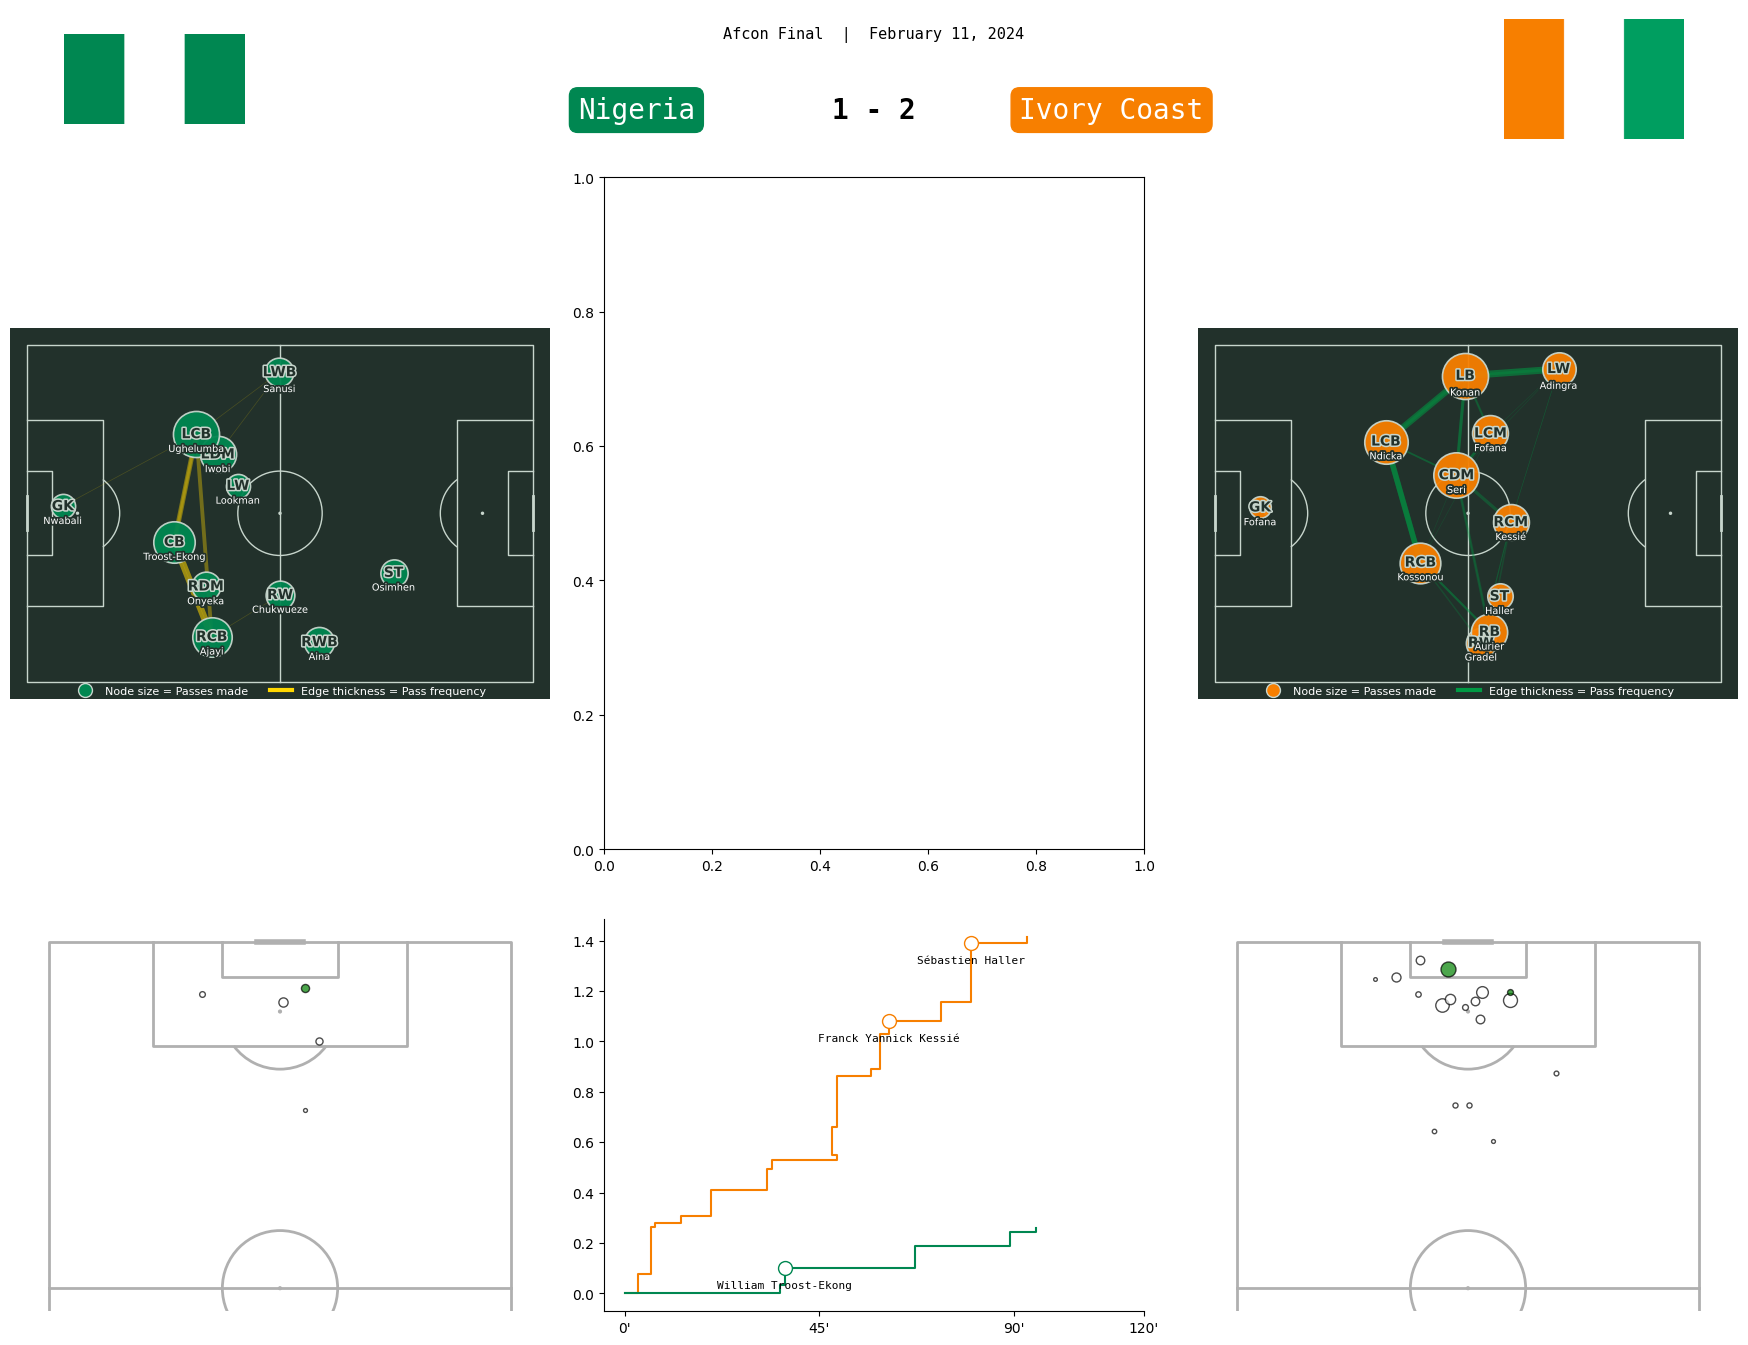

In [85]:
fig = plt.figure(figsize=(18, 14))  # Increased figure size

# Team logos
ax1 = fig.add_axes([.05, .85, .1, .1])
teamA_img = Image.open("../team_logos/nigeria_flag.png")
ax1.imshow(teamA_img)
ax1.axis('off')

# Title and score
ax2 = fig.add_axes([.2, .83, .6, .12])
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.text(.5, .9, 'Afcon Final  |  February 11, 2024', fontsize=11, ha='center', va='top',
         fontdict={'family': 'monospace'})
team_A_text = ax2.text(.28, .4, 'Nigeria', fontsize=20, ha='center', va='center',
                        color='white', fontdict={'family': 'monospace'})
team_A_text.set_bbox(dict(facecolor=NIGERIA_COLOR, alpha=1.0, edgecolor=NIGERIA_COLOR, boxstyle='round'))
ax2.text(.5, .4, '1 - 2', fontsize=20, ha='center', va='center',
         fontweight='bold', fontdict={'family': 'monospace'})
team_B_text = ax2.text(.72, .4, 'Ivory Coast', fontsize=20, ha='center', va='center',
                        color='white', fontdict={'family': 'monospace'})
team_B_text.set_bbox(dict(facecolor=IVORYCOAST_COLOR, alpha=1.0, edgecolor=IVORYCOAST_COLOR, boxstyle='round'))

# Team B logo
ax3 = fig.add_axes([.85, .85, .1, .1])
teamB_img = Image.open("../team_logos/ivorycoast_flag.png")
ax3.imshow(teamB_img)
ax3.axis('off')

# Passing Networks - LARGER AXES
ax4 = fig.add_axes([.02, .35, .30, .48])  # Larger and repositioned
create_passnetwork(
    team_name_str = 'Nigeria',
    ax            = ax4,
    match_id      = match_id,
    node_color    = NIGERIA_COLOR,
    edge_color    = '#FFD700',
)


ax5 = fig.add_axes([.35, .35, .30, .48])  # Middle, larger

ax6 = fig.add_axes([.68, .35, .30, .48])  # Larger and repositioned
create_passnetwork(
    team_name_str = "Côte d'Ivoire",
    ax            = ax6,
    match_id      = match_id,
    node_color    = IVORYCOAST_COLOR,
    edge_color    = '#009A44',
)

# Shotmaps
ax7 = fig.add_axes([.02, .02, .30, .28])
create_shotmap(teamA, ax7)
ax7.axis('off')

ax8 = fig.add_axes([.35, .02, .30, .28])  # This could be stats or empty space
create_xg_flow_chart(
    df,
    ax8
)

ax9 = fig.add_axes([.68, .02, .30, .28])
create_shotmap(teamB, ax9)
ax9.axis('off')

plt.show()